# **Energy density components of the Glasma**

This notebook computes the time evolution of the Glasma energy density and its decomposition into longitudinal/transverse electric and magnetic components $\varepsilon_{E,L}$, $\varepsilon_{E,T}$, $\varepsilon_{B,L}$, $\varepsilon_{B,T}$, as well as the pressure anisotropy $P_T/\varepsilon$ and $P_L/\varepsilon$, averaged over multiple events.

## Setup environment and imports

In [1]:
import os
os.environ["MY_NUMBA_TARGET"] = "cuda"
os.environ["GAUGE_GROUP"] = "su3"
os.environ["PRECISION"] = "double"

import sys
sys.path.append('../..')

import curraun.core as core
import curraun.mv as mv
import curraun.initial as initial
initial.DEBUG = False
from curraun.energy import Energy

from curraun.numba_target import use_cuda
if use_cuda:
    from numba import cuda

import numpy as np
import pickle
from tqdm import tqdm

Using CUDA
Using SU(3)
Using double precision
Using double precision


## Simulation parameters

In [2]:
# hbar * c [GeV * fm]
hbarc = 0.197326

L   = 10.0
N   = 1024
DTS = 8

# Glasma fields
g2mu = 2.0          # g²μ [GeV]
g    = 2.0
mu   = g2mu / g**2  # MV model parameter [GeV]
ir   = 0.2          # infrared regulator [GeV]
uv   = 10.0         # ultraviolet cutoff [GeV]
ns   = 1            # number of color charge sheets

# Derived lattice parameters
a  = L / N
E0 = N / L * hbarc
DT = 1.0 / DTS

TAU_MAX_DIM = 5.0                        # g²μ·τ_max (dimensionless)
TAU_MAX     = TAU_MAX_DIM * hbarc / g2mu  # [fm/c]
maxt        = int(TAU_MAX / a * DTS)

# Number of events for averaging
nevents = 1

# Validity checks
cond1_lhs = 2 * np.pi / L * hbarc
print(f"2π/L  = {cond1_lhs:.4f} < m = {ir}   {'passed' if cond1_lhs < ir else 'FAILED'}")
print(f"m/g²μ = {ir/g2mu:.4f} < 1             {'passed' if ir/g2mu < 1 else 'FAILED'}")
print(f"g²μa  = {g2mu*a/hbarc:.4f} < 1             {'passed' if g2mu*a/hbarc < 1 else 'FAILED'}")
print(f"g²μL  = {g2mu*L/hbarc:.2f}")


2π/L  = 0.1240 < m = 0.2   passed
m/g²μ = 0.1000 < 1             passed
g²μa  = 0.0990 < 1             passed
g²μL  = 101.36


## Simulation routine

For each event: initialize the Glasma with MV model Wilson lines, evolve the fields using the leapfrog algorithm, and record the energy density components $\varepsilon_{E,L}$, $\varepsilon_{E,T}$, $\varepsilon_{B,L}$, $\varepsilon_{B,T}$ at every time step.

In [3]:
def simulate_energy_components(nevents):
    """Run Glasma simulation and record energy density components per event."""

    EL_events, ET_events = [], []
    BL_events, BT_events = [], []
    tau_lat_list = []

    for ev in range(nevents):
        np.random.seed(ev)

        s  = core.Simulation(N, DT, g)
        va = mv.wilson(s, mu=mu/E0, m=ir/E0, uv=uv/E0, num_sheets=ns)
        vb = mv.wilson(s, mu=mu/E0, m=ir/E0, uv=uv/E0, num_sheets=ns)
        initial.init(s, va, vb)

        if use_cuda:
            s.copy_to_device()

        energy = Energy(s)

        EL_ev, ET_ev, BL_ev, BT_ev = [], [], [], []
        tau_lat_ev = []

        with tqdm(total=maxt, desc=f"Event {ev + 1}/{nevents}") as pbar:
            for _ in range(maxt):
                core.evolve_leapfrog(s)
                energy.compute()
                EL_ev.append(energy.EL_mean)
                ET_ev.append(energy.ET_mean)
                BL_ev.append(energy.BL_mean)
                BT_ev.append(energy.BT_mean)
                tau_lat_ev.append(s.t)
                pbar.update(1)

        EL_events.append(EL_ev)
        ET_events.append(ET_ev)
        BL_events.append(BL_ev)
        BT_events.append(BT_ev)
        if ev == 0:
            tau_lat_list = tau_lat_ev

    tau_lat = np.array(tau_lat_list)   # dimensionless lattice time s.t
    tau     = tau_lat * a              # physical proper time [fm/c]

    return {
        "EL": np.array(EL_events),    # shape: (nevents, maxt)
        "ET": np.array(ET_events),
        "BL": np.array(BL_events),
        "BT": np.array(BT_events),
        "tau":     tau,
        "tau_lat": tau_lat,
        "E0": E0, "hbarc": hbarc,
        "g2mu": g2mu, "g": g,
        "N": N, "L": L, "DTS": DTS,
        "nevents": nevents,
    }

## Run simulation and save results

In [4]:
results = simulate_energy_components(nevents)

fname = f"ed_components_g2mu_{g2mu:.1f}.pickle"
with open(fname, "wb") as f:
    pickle.dump(results, f)
print(f"Saved to {fname}")

Event 1/1: 100%|██████████| 404/404 [00:39<00:00, 10.30it/s]

Saved to ed_components_g2mu_2.0.pickle


## Load results and plot

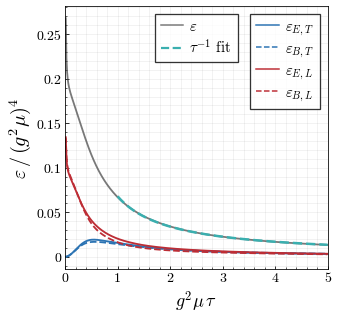

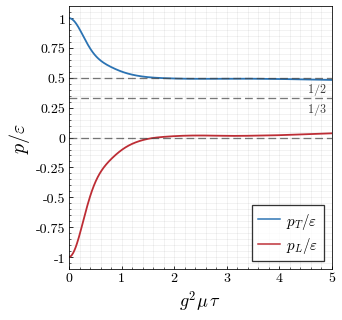

In [5]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit

plt.rcParams['text.usetex']  = False
plt.rcParams['font.family']  = 'serif'
plt.rcParams['font.serif']   = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

fname = f"ed_components_g2mu_{g2mu:.1f}.pickle"
with open(fname, "rb") as f:
    res = pickle.load(f)

hbarc   = res["hbarc"]
E0      = res["E0"]
g2mu    = res["g2mu"]
tau     = res["tau"]
tau_lat = res["tau_lat"]

EL = np.array(res["EL"])
ET = np.array(res["ET"])
BL = np.array(res["BL"])
BT = np.array(res["BT"])

EL_mean, EL_std = np.mean(EL, axis=0), np.std(EL, axis=0)
ET_mean, ET_std = np.mean(ET, axis=0), np.std(ET, axis=0)
BL_mean, BL_std = np.mean(BL, axis=0), np.std(BL, axis=0)
BT_mean, BT_std = np.mean(BT, axis=0), np.std(BT, axis=0)

def to_norm(mean, std):
    scale = (E0 / g2mu)**4 / tau_lat
    return mean * scale, std * scale

EL_norm, EL_nerr = to_norm(EL_mean, EL_std)
ET_norm, ET_nerr = to_norm(ET_mean, ET_std)
BL_norm, BL_nerr = to_norm(BL_mean, BL_std)
BT_norm, BT_nerr = to_norm(BT_mean, BT_std)
epsilon_norm = EL_norm + ET_norm + BL_norm + BT_norm

total = EL_mean + ET_mean + BL_mean + BT_mean
pT    = (EL_mean + BL_mean) / total
pL    = (ET_mean + BT_mean - EL_mean - BL_mean) / total

x      = tau * g2mu / hbarc
xlims  = (0, TAU_MAX_DIM)


def _fmt_ax(ax, xlabel=None, ylabel=None, xlims=None, fontsize=14):
    if xlims:
        ax.set_xlim(*xlims)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))
    ax.tick_params(axis='both', which='major', direction='in', labelsize=fontsize)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
    ax.set_box_aspect(1)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=fontsize + 4)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=fontsize + 6)


def _add_legend(ax, handles, loc='upper right', fontsize=15):
    leg = ax.legend(handles=handles, fontsize=fontsize, frameon=True, loc=loc,
                    facecolor='white', edgecolor='black',
                    handlelength=1.5, borderpad=0.4, shadow=False,
                    handletextpad=0.4, labelspacing=0.3)
    leg.get_frame().set_linewidth(1.3)
    leg.get_frame().set_boxstyle('square', pad=0)
    return leg


# Sample RdBu at slightly darker positions than the previous 0.20/0.80
rdbu = cm.get_cmap('RdBu')
c_L   = rdbu(0.13)   # darker red — longitudinal
c_T   = rdbu(0.87)   # darker blue — transverse
c_ref = '#404040'    # dark gray for reference lines, labels, and ε
c_fit = '#3aafaf'    # darker pastel teal for the τ⁻¹ fit

xlabel_str = r'$g^2\mu\,\tau$'

# 1/τ fit on epsilon_norm for g²μτ >= 1
fit_mask   = x >= 1.0
popt, _    = curve_fit(lambda xv, A: A / xv, x[fit_mask], epsilon_norm[fit_mask], p0=[1.0])
A_fit      = popt[0]
x_fit_plot = np.linspace(1.0, xlims[1], 200)
y_fit_plot = A_fit / x_fit_plot

# ── Figure 1: energy density components ──────────────────────────────────────
fig_e, ax_e = plt.subplots(1, 1, figsize=(5.5, 4.5))
fig_e.subplots_adjust(left=0.16, right=0.95, bottom=0.14, top=0.95)

# T lines (darker blue): ET solid with error band, BT dashed (no band)
ax_e.plot(x, ET_norm, color=c_T, linewidth=1.8)
ax_e.fill_between(x, ET_norm - ET_nerr, ET_norm + ET_nerr, color=c_T, alpha=0.2)
ax_e.plot(x, BT_norm, color=c_T, linewidth=1.8, linestyle='--')

# L lines (darker red): EL solid with error band, BL dashed (no band)
ax_e.plot(x, EL_norm, color=c_L, linewidth=1.8)
ax_e.fill_between(x, EL_norm - EL_nerr, EL_norm + EL_nerr, color=c_L, alpha=0.2)
ax_e.plot(x, BL_norm, color=c_L, linewidth=1.8, linestyle='--')

# Total ε: dark gray with alpha so it reads as gray, not black
ax_e.plot(x, epsilon_norm, color=c_ref, linewidth=1.8, alpha=0.7)

# Fit: darker pastel teal, thicker, dashed
ax_e.plot(x_fit_plot, y_fit_plot, color=c_fit, linewidth=2.5, linestyle='--')

_fmt_ax(ax_e, xlabel=xlabel_str,
        ylabel=r'$\varepsilon\,/\,(g^2\mu)^4$', xlims=xlims)

# Legend 1: components — T first (blue), then L (red); E solid, B dashed
leg1 = _add_legend(ax_e, [
    Line2D([0], [0], color=c_T, linewidth=1.5,                 label=r'$\varepsilon_{E,T}$'),
    Line2D([0], [0], color=c_T, linewidth=1.5, linestyle='--', label=r'$\varepsilon_{B,T}$'),
    Line2D([0], [0], color=c_L, linewidth=1.5,                 label=r'$\varepsilon_{E,L}$'),
    Line2D([0], [0], color=c_L, linewidth=1.5, linestyle='--', label=r'$\varepsilon_{B,L}$'),
], loc='upper right')
ax_e.add_artist(leg1)

# Legend 2: ε and fit — upper center
_add_legend(ax_e, [
    Line2D([0], [0], color=c_ref, linewidth=1.5, alpha=0.7,        label=r'$\varepsilon$'),
    Line2D([0], [0], color=c_fit, linewidth=2.2, linestyle='--', label=r'$\tau^{-1}$ fit'),
], loc='upper center')

fig_e.savefig("ed_components.pdf", bbox_inches='tight')
fig_e.savefig("ed_components.png", bbox_inches='tight', dpi=200)
plt.show()

# ── Figure 2: pressure anisotropy ────────────────────────────────────────────
fig_p, ax_p = plt.subplots(1, 1, figsize=(5.5, 4.5))
fig_p.subplots_adjust(left=0.14, right=0.95, bottom=0.14, top=0.95)

ax_p.plot(x, pT, color=c_T, linewidth=1.8)
ax_p.plot(x, pL, color=c_L, linewidth=1.8)

for yval in [0.0, 1/3, 1/2]:
    ax_p.axhline(yval, color=c_ref, linewidth=1.3, linestyle=(0, (6, 3)), alpha=0.7)

ax_p.text(xlims[1] - 0.10, 1/2 - 0.03, r'$1/2$', ha='right', va='top',
          fontsize=12, color=c_ref)
ax_p.text(xlims[1] - 0.10, 1/3 - 0.03, r'$1/3$', ha='right', va='top',
          fontsize=12, color=c_ref)

_fmt_ax(ax_p, xlabel=xlabel_str, ylabel=r'$p/\varepsilon$', xlims=xlims)

_add_legend(ax_p, [
    Line2D([0], [0], color=c_T, linewidth=1.5, label=r'$p_T/\varepsilon$'),
    Line2D([0], [0], color=c_L, linewidth=1.5, label=r'$p_L/\varepsilon$'),
], loc='lower right')

# fig_p.savefig("ed_pressure.pdf", bbox_inches='tight')
# fig_p.savefig("ed_pressure.png", bbox_inches='tight', dpi=200)
plt.show()